In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\ROHIT RANE\Downloads\ai4i2020.csv")
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  object 
 2   Type                     10000 non-null  object 
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9)

In [4]:
df = df.iloc[:, 2:-5]

In [5]:
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure
0,M,298.1,308.6,1551,42.8,0,0
1,L,298.2,308.7,1408,46.3,3,0
2,L,298.1,308.5,1498,49.4,5,0
3,L,298.2,308.6,1433,39.5,7,0
4,L,298.2,308.7,1408,40.0,9,0


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
encoder = LabelEncoder()

In [8]:
df['TypeEncoder'] = encoder.fit_transform(df['Type'])
df.head()

,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TypeEncoder
0,M,298.1,308.6,1551,42.8,0,0,2
1,L,298.2,308.7,1408,46.3,3,0,1
2,L,298.1,308.5,1498,49.4,5,0,1
3,L,298.2,308.6,1433,39.5,7,0,1
4,L,298.2,308.7,1408,40.0,9,0,1


In [9]:
df.drop(columns = ['Type'], axis = 1, inplace = True)

In [10]:
df.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TypeEncoder
0,298.1,308.6,1551,42.8,0,0,2
1,298.2,308.7,1408,46.3,3,0,1
2,298.1,308.5,1498,49.4,5,0,1
3,298.2,308.6,1433,39.5,7,0,1
4,298.2,308.7,1408,40.0,9,0,1


In [11]:
x = df.drop(columns = ['Machine failure'], axis = 1)
y = df['Machine failure']

In [12]:
x.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TypeEncoder
0,298.1,308.6,1551,42.8,0,2
1,298.2,308.7,1408,46.3,3,1
2,298.1,308.5,1498,49.4,5,1
3,298.2,308.6,1433,39.5,7,1
4,298.2,308.7,1408,40.0,9,1


In [13]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: Machine failure, dtype: int64

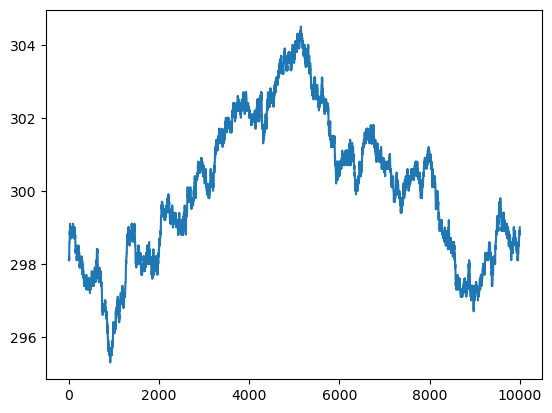

In [14]:
plt.plot(x['Air temperature [K]'])

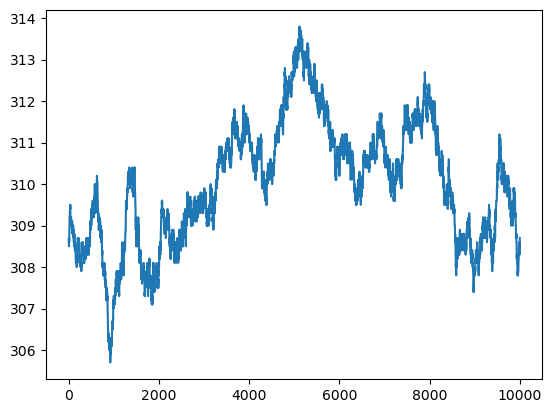

In [15]:
plt.plot(x['Process temperature [K]'])

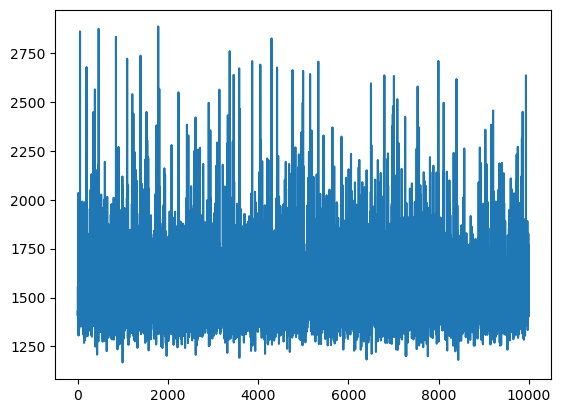

In [16]:
plt.plot(x['Rotational speed [rpm]'])

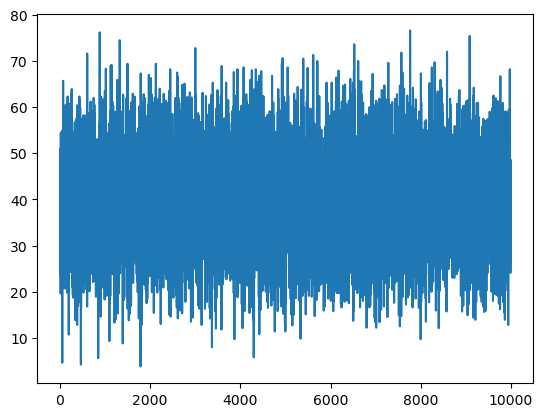

In [17]:
plt.plot(x['Torque [Nm]'])

In [18]:
x.head()

,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],TypeEncoder
0,298.1,308.6,1551,42.8,0,2
1,298.2,308.7,1408,46.3,3,1
2,298.1,308.5,1498,49.4,5,1
3,298.2,308.6,1433,39.5,7,1
4,298.2,308.7,1408,40.0,9,1


In [19]:
from sklearn.model_selection import train_test_split

In [20]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size = 0.2, random_state = 42, stratify = y)

In [21]:
x_train.shape

(8000, 6)

In [22]:
y_train.shape

(8000,)

In [23]:
from imblearn.over_sampling import SMOTE

In [24]:
smote = SMOTE()

In [25]:
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train)

In [26]:
from sklearn.preprocessing import StandardScaler

In [27]:
sc = StandardScaler()

In [28]:
x_train_scaled = sc.fit_transform(x_train_smote)
x_test_scaled = sc.transform(x_test)

In [29]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, f1_score
from sklearn.model_selection import GridSearchCV
import joblib

In [30]:
models = {
    'Logistic Regression' : LogisticRegression(max_iter = 1000,
                                               random_state = 42),
    'Decision Tree Classifier' : DecisionTreeClassifier(),
    'KNN' : KNeighborsClassifier(n_neighbors = 10),
    'Random Forest Classifier' : RandomForestClassifier(n_estimators = 1000,
                                                        random_state = 42),
}

result = []

for name, model in models.items():

    model.fit(x_train_smote, y_train_smote)

    y_pred = model.predict(x_test)
    y_prob = model.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)
    
    result.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "F1 Score": round(f1, 4),
        "ROC AUC": round(roc, 4)
    })

    print("="*50)
    print(name)
    print("="*50)
    print(classification_report(y_test, y_pred))

# ====================================
# Summary Table
# ====================================

result_df = pd.DataFrame(result)

result_df = result_df.sort_values(
    by="ROC AUC",
    ascending=False
)

result_df.index = range(1, len(result_df) + 1)

print("\n" + "="*60)
print("              MODEL COMPARISON SUMMARY")
print("="*60)

print(result_df.to_string())

# ====================================
# Best Model
# ====================================

best_model = result_df.iloc[0]

print("\n" + "="*60)
print("BEST MODEL")
print("="*60)

print(f"Model     : {best_model['Model']}")
print(f"Accuracy  : {best_model['Accuracy']}")
print(f"F1 Score  : {best_model['F1 Score']}")
print(f"ROC AUC   : {best_model['ROC AUC']}")

Logistic Regression
              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1932
           1       0.15      0.79      0.26        68

    accuracy                           0.84      2000
   macro avg       0.57      0.82      0.58      2000
weighted avg       0.96      0.84      0.89      2000

Decision Tree Classifier
              precision    recall  f1-score   support

           0       0.99      0.95      0.97      1932
           1       0.36      0.75      0.49        68

    accuracy                           0.95      2000
   macro avg       0.68      0.85      0.73      2000
weighted avg       0.97      0.95      0.96      2000

KNN
              precision    recall  f1-score   support

           0       0.99      0.89      0.94      1932
           1       0.18      0.69      0.29        68

    accuracy                           0.88      2000
   macro avg       0.58      0.79      0.61      2000
weighted avg       0.96  

In [31]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    f1_score,
    roc_auc_score,
    classification_report
)

import pandas as pd
import joblib

# =====================================================
# Models and Hyperparameters
# =====================================================

models = {

    "Logistic Regression": {
        "model": LogisticRegression(random_state=42),
        "params": {
            "C": [0.01, 0.1, 1, 10],
            "max_iter": [500, 1000]
        }
    },

    "Decision Tree Classifier": {
        "model": DecisionTreeClassifier(random_state=42),
        "params": {
            "criterion": ["gini", "entropy"],
            "max_depth": [5, 10, 15, None],
            "min_samples_split": [2, 5, 10]
        }
    },

    "KNN": {
        "model": KNeighborsClassifier(),
        "params": {
            "n_neighbors": [3, 5, 7, 10],
            "weights": ["uniform", "distance"]
        }
    },

    "Random Forest Classifier": {
        "model": RandomForestClassifier(random_state=42),
        "params": {
            "n_estimators": [100, 200, 300],
            "max_depth": [5, 10, 20, None],
            "min_samples_split": [2, 5],
            "criterion": ["gini", "entropy"]
        }
    }

}

# =====================================================
# Training
# =====================================================

result = []

best_model = None
best_model_name = ""
best_params = None
best_score = 0

for name, model in models.items():

    grid = GridSearchCV(
        estimator=model["model"],
        param_grid=model["params"],
        cv=5,
        scoring="f1",
        n_jobs=-1
    )

    grid.fit(x_train_smote, y_train_smote)

    y_pred = grid.predict(x_test)
    y_prob = grid.predict_proba(x_test)[:, 1]

    accuracy = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    roc = roc_auc_score(y_test, y_prob)

    # Store Best Model
    if roc > best_score:
        best_score = roc
        best_model = grid.best_estimator_
        best_model_name = name
        best_params = grid.best_params_

    result.append({
        "Model": name,
        "Accuracy": round(accuracy, 4),
        "F1 Score": round(f1, 4),
        "ROC AUC": round(roc, 4)
    })

    print("=" * 60)
    print(name)
    print("=" * 60)
    print("Best Parameters:")
    print(grid.best_params_)
    print()
    print(classification_report(y_test, y_pred))

# =====================================================
# Summary Table
# =====================================================

result_df = pd.DataFrame(result)

result_df = result_df.sort_values(
    by="ROC AUC",
    ascending=False
)

result_df.index = range(1, len(result_df) + 1)

print("\n" + "=" * 60)
print("MODEL COMPARISON SUMMARY")
print("=" * 60)

print(result_df.to_string())

# =====================================================
# Best Model Details
# =====================================================

print("\n" + "=" * 60)
print("BEST MODEL")
print("=" * 60)

print(f"Model Name     : {best_model_name}")
print(f"Accuracy       : {result_df.iloc[0]['Accuracy']}")
print(f"F1 Score       : {result_df.iloc[0]['F1 Score']}")
print(f"ROC AUC        : {best_score}")
print(f"Best Parameters: {best_params}")

# =====================================================
# Save Best Tuned Model
# =====================================================

joblib.dump(
    best_model,
    "predictive_maintenance_model.pkl"
)

print("\nBest tuned model saved successfully.")

Logistic Regression
Best Parameters:
{'C': 0.1, 'max_iter': 500}

              precision    recall  f1-score   support

           0       0.99      0.84      0.91      1932
           1       0.15      0.79      0.25        68

    accuracy                           0.84      2000
   macro avg       0.57      0.82      0.58      2000
weighted avg       0.96      0.84      0.89      2000

Decision Tree Classifier
Best Parameters:
{'criterion': 'entropy', 'max_depth': None, 'min_samples_split': 2}

              precision    recall  f1-score   support

           0       0.99      0.96      0.97      1932
           1       0.37      0.65      0.47        68

    accuracy                           0.95      2000
   macro avg       0.68      0.80      0.72      2000
weighted avg       0.97      0.95      0.96      2000

KNN
Best Parameters:
{'n_neighbors': 3, 'weights': 'distance'}

              precision    recall  f1-score   support

           0       0.98      0.91      0.95      1